# Replay: watching the policy, and reshaping the spec

A replay tool for the Q-Learning agent trained in **gaussian-gates.ipynb**, built around the STL
reading of the reward function. Two matplotlib figures:

1. **The replay dashboard** — plays back an episode on the course, step by step, for any checkpoint
   of training. Scrub the steps, jump from the untrained policy to the final one, and watch the
   reward accumulate, the safety robustness rise and fall, and both split into the clauses of the
   spec that produced them.
2. **The reward-shaping panel** — sliders and text inputs for the four reward lambdas and for $R$,
   the threshold of the safety predicate. Changing any of them changes *what the agent is being
   asked to do*, so nothing is learned until you press **Train**: that reruns Q-Learning under the
   new spec and hands the fresh run to the dashboard.

### The spec

$$\text{cross } G_1 \ldots G_n \text{ in order, return through } G_1,\;
\square\,(d \geq R),\; \text{as fast as possible}$$

The gate clauses are **events**: a crossing either happened or it did not, and any valid crossing
pays the same $\lambda_{midpoint}$ wherever along the gate it happens.

The safety clause is scored as **robustness**. With $d$ the distance from the step's movement
segment to the nearest pylon, the predicate $\square\,(d \geq R)$ has robustness

$$\rho = d - R$$

— positive by the margin you cleared it with, negative by the meters you are inside it. Every step
is charged $\lambda_{field}$ per meter of violation, so the penalty grows continuously as the agent
closes on a pylon instead of arriving all at once on contact. $R$ is the threshold you adjust; it is
drawn on the course as a dashed ring, shaded by how expensive each point inside it is.

Touching a pylon still ends the episode but carries no penalty of its own — a collision is simply
the deepest violation the field can score, and forfeiting the rest of the lap does the rest.

Because the gates *are* pylon-to-pylon segments, the safety field is also what keeps crossings away
from the gate ends. The "cross near the middle" behaviour is no longer paid for directly; it falls
out of the safety predicate.

The environment, the spec monitor and the Q-Learning agent are imported from `race_env.py`, the
module `gaussian-gates.ipynb` shares with this notebook.

**Setup** (once): `pip install ipympl ipywidgets`, then restart the kernel. Without them the
`%matplotlib widget` line below falls back to a static backend and the sliders will not respond.

In [12]:
%matplotlib widget
# ipympl's backend: it is what makes matplotlib's own Slider/Button/TextBox widgets live
# inside the notebook. Install once with:  pip install ipympl ipywidgets

import sys
sys.path.insert(0, "")  # this notebook's folder, where race_env.py lives

import hashlib
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from matplotlib.widgets import Button, Slider, TextBox

from race_env import Action, RaceEnv, GateSequenceMonitor, q_learning_with_logging

## Configuration

The course and hyperparameters match `gaussian-gates.ipynb`, so a run here is the same run there.
The lambdas below are only *defaults* — the panel's sliders are what you'll actually vary.
`N_EPISODES` is the one knob worth tuning for comfort: 4,000 episodes trains in ~17s and laps the
course reliably; 10,000 (~45s) reproduces the notebook exactly.

$\lambda_{field}$ is in **reward per meter of violation**, not reward per event: at the defaults
($R$ = 2.5m, $\lambda_{field}$ = -300) a step taken right at a pylon's surface costs
$-300 \times (2.5 - 0.25) = -675$, and a step outside the ring costs nothing.

In [13]:
COURSE_PATH = "../../ros2_ws/src/pylon_2026_world/purt_course.yaml"
CELL_SIZE_M = 1.0              # grid resolution for discretizing agent position -- matches gaussian-gates.ipynb
MAX_STEPS = 400
NOISE = 0.25
DISCOUNT_FACTOR = 0.99
ALPHA = 0.1
EPSILON = 0.3
SNAPSHOT_EVERY = 50            # a greedy-policy snapshot every 50 episodes -- these are the replay's checkpoints
N_EPISODES = 4000              # default for the Train button (~15s); 10000 reproduces gaussian-gates (~40s)
TRAIN_SEED = 0
ROLLOUT_SEED = 0
PROGRESS_REFRESH_S = 0.3       # how often training pushes its progress bar to the browser (~27ms each)

# The four lambdas of the reward function, one per clause of the spec. Signs are baked into the
# values (not the slider), so they read the same as the REWARDS dict. "pylon_field" is special: it
# is a reward *per meter* of safety violation, charged on every step that sits inside the radius.
DEFAULT_LAMBDAS = {"neutral": -1.0, "midpoint": 1000.0, "endpoint": 1000.0, "pylon_field": -300.0}
LAMBDA_RANGES = {"neutral": (-20.0, 0.0), "midpoint": (0.0, 3000.0),
                 "endpoint": (0.0, 3000.0), "pylon_field": (-2000.0, 0.0)}
PART_KEYS = ("neutral", "midpoint", "endpoint", "pylon_field")
PART_LABELS = {"neutral": "time  $\\lambda_{neutral}$", "midpoint": "gates  $\\lambda_{midpoint}$",
               "endpoint": "finish  $\\lambda_{endpoint}$", "pylon_field": "pylon field  $\\lambda_{field}$"}
PART_SLIDER_LABELS = {"neutral": "$\\lambda_{neutral}$", "midpoint": "$\\lambda_{midpoint}$",
                      "endpoint": "$\\lambda_{endpoint}$", "pylon_field": "$\\lambda_{field}$ (per m)"}
PART_COLORS = {"neutral": "slategray", "midpoint": "darkorange", "endpoint": "goldenrod", "pylon_field": "firebrick"}
FIELD_R_RANGE = (0.25, 10.0)   # the STL threshold R, in meters -- never below the pylons' own radius

CACHE_DIR = Path("replay_cache")   # trained runs are cached here, keyed by lambdas + hyperparameters

# A throwaway env, used only to read course geometry (gate lengths, the course's own safety margin)
# for the widgets' defaults and the gate-weight preview.
PROBE_ENV = RaceEnv(COURSE_PATH, CELL_SIZE_M=CELL_SIZE_M, MAX_STEPS=MAX_STEPS, NOISE=NOISE)
DEFAULT_FIELD_R_M = PROBE_ENV.PYLON_FIELD_R_M    # the course's own safety margin: 2.5m
PYLON_R_M = float(min(p["r"] for p in PROBE_ENV.PYLONS))   # physical pylon radius: the deepest a violation can go

## Training runs, and why they are cached

A change to the spec is not a display setting — the agent has to relearn under it. Each press of
**Train** is therefore a full Q-Learning run, and each run is saved to `replay_cache/` under a hash
of the lambdas, the radius, and every hyperparameter that affects learning. Training is seeded, so
a cached run is bit-for-bit the run you would get by training again: revisiting a spec you have
already tried is instant, and comparing two specs back-to-back costs nothing after the first time.

A `TrainingRun` holds the greedy policy at every checkpoint (one snapshot per `SNAPSHOT_EVERY`
episodes) plus the per-episode returns — everything the two figures need, and nothing else.

In [14]:
def make_env(lambdas, field_radius_m):
    # One env per reward setting: the lambdas live in the monitor, the safety threshold R in the
    # course env (it is a property of the predicate over the course, not of the reward's scaling).
    return GateSequenceMonitor(
        RaceEnv(COURSE_PATH, CELL_SIZE_M=CELL_SIZE_M, MAX_STEPS=MAX_STEPS, NOISE=NOISE,
                PYLON_FIELD_R_M=float(field_radius_m)),
        {k: float(v) for k, v in lambdas.items()},
    )


class TrainingRun:
    # One Q-Learning run under one reward setting: the greedy policy at every checkpoint, plus the
    # per-episode returns that show how (and whether) it learned.
    def __init__(self, lambdas, field_radius_m, n_episodes, seed, episodes, policies, trajectory_rewards):
        self.lambdas = dict(lambdas)
        self.field_radius_m = float(field_radius_m)
        self.n_episodes = int(n_episodes)
        self.seed = int(seed)
        self.episodes = np.asarray(episodes, dtype=np.int32)          # episode number of each snapshot
        self.policies = np.asarray(policies, dtype=np.int8)           # (n_checkpoints, n_cells, n_q)
        self.trajectory_rewards = np.asarray(trajectory_rewards, dtype=np.float32)

    @property
    def n_checkpoints(self):
        return len(self.episodes)

    def policy(self, i):
        return self.policies[int(np.clip(i, 0, self.n_checkpoints - 1))]

    def key_checkpoints(self):
        # The snapshots worth jumping straight to: the untrained start, a few points through the
        # early climb (where most of the change happens), the midpoint, and the final policy.
        targets = [0.0, 0.02, 0.05, 0.10, 0.25, 0.50, 1.0]
        idx = [int(round(f * (self.n_checkpoints - 1))) for f in targets]
        return sorted(set(idx))

    def lambda_summary(self):
        names = {"neutral": "neutral", "midpoint": "midpoint", "endpoint": "endpoint", "pylon_field": "field"}
        return "  ".join(f"$\\lambda_{{{names[k]}}}$={self.lambdas[k]:g}" for k in PART_KEYS) + \
               f"   $R$={self.field_radius_m:g}m"


def run_key(lambdas, field_radius_m, n_episodes, seed):
    # Cache identity: everything that changes what gets learned. Hyperparameters are included so a
    # config edit can never serve a stale run.
    payload = {
        "lambdas": {k: round(float(lambdas[k]), 6) for k in sorted(lambdas)},
        "field_radius_m": round(float(field_radius_m), 6), "n_episodes": int(n_episodes), "seed": int(seed),
        "cell_size_m": CELL_SIZE_M, "max_steps": MAX_STEPS, "noise": NOISE, "alpha": ALPHA,
        "epsilon": EPSILON, "discount_factor": DISCOUNT_FACTOR, "snapshot_every": SNAPSHOT_EVERY,
        "course": COURSE_PATH,
    }
    return hashlib.md5(json.dumps(payload, sort_keys=True).encode()).hexdigest()[:12], payload


def train_or_load(lambdas, field_radius_m, n_episodes=N_EPISODES, seed=TRAIN_SEED,
                  progress_callback=None, use_cache=True):
    # Returns (run, was_cached). Training is seeded, so a cached run is exactly the run you'd get
    # by training again -- which is what makes caching safe here.
    key, payload = run_key(lambdas, field_radius_m, n_episodes, seed)
    path = CACHE_DIR / f"run_{key}.npz"
    if use_cache and path.exists():
        with np.load(path, allow_pickle=False) as z:
            return TrainingRun(lambdas, field_radius_m, n_episodes, seed,
                               z["episodes"], z["policies"], z["trajectory_rewards"]), True

    np.random.seed(seed)
    env = make_env(lambdas, field_radius_m)
    _, _, trajectory_rewards, policy_history = q_learning_with_logging(
        env, DISCOUNT_FACTOR, ALPHA, EPSILON, int(n_episodes), SNAPSHOT_EVERY,
        progress_callback=progress_callback,
    )
    run = TrainingRun(lambdas, field_radius_m, n_episodes, seed,
                      [s["episode"] for s in policy_history],
                      np.stack([s["policy"].astype(np.int8) for s in policy_history]),
                      trajectory_rewards)
    CACHE_DIR.mkdir(exist_ok=True)
    np.savez_compressed(path, episodes=run.episodes, policies=run.policies,
                        trajectory_rewards=run.trajectory_rewards, meta=json.dumps(payload))
    return run, False

## Capturing an episode

Replay needs a recorded episode, not a live one: scrubbing backwards through a simulation you are
still stepping is not possible. `capture_rollout` plays one checkpoint's greedy policy to the end
and records each step — position, action, spec state `q`, the step's reward broken into its named
parts, any gate crossing, and the step's safety robustness $\rho$. Scrubbing then just reads the
list.

The per-step $\rho$ values form the episode's **robustness trace**. Its minimum is the robustness
of $\square\,(d \geq R)$ over the whole episode: one number saying how safe the lap really was,
positive only if the agent never once entered the radius.

The env's action noise (`NOISE=0.25`) still applies, so a rollout is one sample of the policy's
behaviour, not the policy itself — hence the seed, and the dashboard's **Re-roll episode** button.

In [15]:
class Rollout:
    # A single episode played by one checkpoint's greedy policy, recorded step by step so the replay
    # can scrub through it without re-simulating.
    def __init__(self, path_xy, frames, checkpoint_index, episode, rollout_seed):
        self.path_xy = path_xy                  # (n_steps + 1, 2) positions in meters, incl. the start
        self.frames = frames                    # one dict per step
        self.checkpoint_index = int(checkpoint_index)
        self.episode = int(episode)
        self.rollout_seed = int(rollout_seed)
        self.cum_reward = np.array([f["cum_reward"] for f in frames], dtype=float)
        # The robustness trace: rho = d - R at every step. Its minimum is the STL robustness of
        # always(d >= R) over the whole episode -- one number saying how safe the lap really was.
        self.robustness = np.array([f["robustness"] for f in frames], dtype=float)
        self.min_robustness = float(self.robustness.min()) if frames else float("nan")
        self.gate_steps = [i for i, f in enumerate(frames) if f["gate_name"] is not None]
        self.totals = {k: (frames[-1]["cum_parts"][k] if frames else 0.0) for k in PART_KEYS}

    def __len__(self):
        return len(self.frames)

    @property
    def outcome(self):
        if not self.frames:
            return "no steps taken"
        last = self.frames[-1]
        if last["lap_finished"]:
            return f"completed the lap in {len(self.frames)} steps"
        if last["hit_pylon"]:
            return f"clipped a pylon at step {len(self.frames)}"
        if last["out_of_bounds"]:
            return f"drove into the bounds at step {len(self.frames)}"
        if last["truncated"]:
            return f"timed out after {len(self.frames)} steps"
        return f"ended after {len(self.frames)} steps"


def capture_rollout(run, checkpoint_index, rollout_seed=ROLLOUT_SEED):
    # Greedy rollout of one snapshot's policy. The env's action noise still applies (NOISE=0.25), so
    # the seed is part of the identity of a replay -- "Re-roll" just bumps it.
    policy = run.policy(checkpoint_index)
    env = make_env(run.lambdas, run.field_radius_m)
    np.random.seed(rollout_seed)
    state, _ = env.reset()

    path_xy = [env.unwrapped.grid_to_xy(int(state[0]))]
    frames, cum_reward, cum_parts = [], 0.0, {k: 0.0 for k in PART_KEYS}
    while True:
        action = int(policy[int(state[0]), int(state[1])])
        state, reward, done, truncated, info = env.step(action)
        cum_reward += reward
        for k in PART_KEYS:
            cum_parts[k] += info["reward_parts"][k]
        path_xy.append(np.asarray(info["new_xy"], dtype=float))
        frames.append({
            "action": action, "q": int(state[1]), "reward": float(reward),
            "parts": dict(info["reward_parts"]), "cum_reward": cum_reward, "cum_parts": dict(cum_parts),
            "gate_name": info["gate_name"], "gate_u": info["gate_u"],
            "robustness": float(info["pylon_robustness"]), "nearest_pylon_m": float(info["nearest_pylon_m"]),
            "hit_pylon": bool(info["hit_pylon"]), "out_of_bounds": bool(info["out_of_bounds"]),
            "lap_finished": bool(info["lap_finished"]), "done": bool(done), "truncated": bool(truncated),
        })
        if done or truncated:
            break

    return Rollout(np.asarray(path_xy), frames, checkpoint_index,
                   int(run.episodes[checkpoint_index]), rollout_seed)

## Is this episode typical?

One replayed episode can flatter or libel a policy. A few extra noisy rollouts give the honest
numbers — how often this checkpoint completes the lap, and how close it came to a pylon doing it —
which the dashboard shows alongside the outcome of the episode being replayed.

In [16]:
def evaluate_policy(run, checkpoint_index, n_episodes=10, seed=10_000):
    # How good is this snapshot, beyond the one episode being replayed? Rolls the greedy policy out
    # a few times under the env's action noise and reports how often it finishes the lap -- and how
    # close it came to a pylon doing it, which is the STL robustness of the safety clause.
    policy = run.policy(checkpoint_index)
    env = make_env(run.lambdas, run.field_radius_m)
    np.random.seed(seed)
    laps, returns, steps, worst_rho = 0, [], [], []
    for _ in range(n_episodes):
        state, _ = env.reset()
        total, n, rho_min = 0.0, 0, float("inf")
        while True:
            state, reward, done, truncated, info = env.step(int(policy[int(state[0]), int(state[1])]))
            total += reward
            n += 1
            rho_min = min(rho_min, info["pylon_robustness"])
            if info["lap_finished"]:
                laps += 1
            if done or truncated:
                break
        returns.append(total)
        steps.append(n)
        worst_rho.append(rho_min)
    return laps / n_episodes, float(np.mean(returns)), float(np.mean(steps)), float(np.mean(worst_rho))

## The replay dashboard

Everything is a plain matplotlib widget, so the tool is one figure with no separate UI layer.

| Control | What it does |
| --- | --- |
| **step** | Scrubs through the recorded episode. The path grows, the marker shows the action taken, the green gate is the one the spec wants next. |
| **checkpoint** | Which training snapshot to replay — drag from the untrained policy at episode 0 to the final one. The readout shows the episode number. |
| **steps/s** | Playback speed. |
| **Play / Restart** | Animate the episode, or jump back to the start line. |
| **Re-roll episode** | Same policy, fresh draw of the action noise. |
| **First / Final / Next key ckpt** | Jump to the start of training, the end, or cycle the handful of checkpoints where the behaviour actually changes (early training moves fastest, so they are spaced logarithmically). |

The course shows the safety field directly: a dashed ring at $R$ around each pylon, shaded by how
much a step there would cost. A dotted orange ring appears when the panel's $R$ slider has been
moved but not yet trained on — that is the spec you are *about* to ask for, next to the one the
replayed policy actually learned.

The right-hand column reads the reward three ways: the cumulative curve with a sweep line and
dotted markers at gate crossings; the robustness trace $\rho = d - R$, with everything below the
red zero line being spec violation; and the running split by clause — time, gates, finish, and the
pylon field.

In [17]:
def push_figure(fig):
    # Repaint the browser's copy of a figure *now*, from inside a blocking call.
    # canvas.draw_idle() only asks the front end to request a fresh image, and a kernel busy in a
    # training loop cannot answer that request until it finishes -- which is why a status line set
    # during training never appeared. canvas.draw() renders and pushes the image itself.
    try:
        fig.canvas.draw()
    except Exception:
        pass


ACTION_MARKERS = {Action.Up.value: "^", Action.Down.value: "v", Action.Left.value: "<", Action.Right.value: ">"}

# The course's real extent, used to rasterize the pylon field behind the course
_X0, _Y0 = PROBE_ENV.ORIGIN
_X1 = _X0 + (PROBE_ENV.GRID_NX - 1) * CELL_SIZE_M
_Y1 = _Y0 + (PROBE_ENV.GRID_NY - 1) * CELL_SIZE_M


class ReplayDashboard:
    # Plays back a checkpoint's greedy rollout on the course, with a step scrubber, a checkpoint
    # slider over the training snapshots, and a live reward readout. Every widget here is a plain
    # matplotlib widget, so the whole thing is one figure -- no HTML, no separate UI layer.
    def __init__(self, run, rollout_seed=ROLLOUT_SEED, figsize=(13.0, 8.6)):
        self.run = run
        self.rollout_seed = int(rollout_seed)
        self.panel = None            # set by RewardPanel so the two figures can talk
        self._playing = False

        self.fig = plt.figure(figsize=figsize)
        for attr, value in (("header_visible", False), ("footer_visible", False)):
            try:                      # ipympl-only chrome; harmless elsewhere
                setattr(self.fig.canvas, attr, value)
            except AttributeError:
                pass

        self.ax_course = self.fig.add_axes([0.045, 0.345, 0.55, 0.605])
        self.ax_cum = self.fig.add_axes([0.685, 0.745, 0.28, 0.205])
        self.ax_rob = self.fig.add_axes([0.685, 0.505, 0.28, 0.165])
        self.ax_parts = self.fig.add_axes([0.685, 0.305, 0.28, 0.135])

        self._build_course_backdrop()
        self._build_reward_axes()
        self._build_widgets()

        self.set_field(run.field_radius_m, run.lambdas["pylon_field"])
        self.rollout = capture_rollout(self.run, self.run.n_checkpoints - 1, self.rollout_seed)
        self._load_rollout(self.rollout, goto_end=False)

    # ---- static course backdrop -----------------------------------------------------------------
    def _build_course_backdrop(self):
        ax = self.ax_course
        # show_path/show_field=False: the bare course. The agent's path and the safety field are
        # animated on top, by us -- both change as you scrub and as you reshape the reward.
        PROBE_ENV.render(ax=ax, title=None, legend_outside=False, show_path=False, show_field=False)
        ax.set_xlabel(""); ax.set_ylabel("")
        xlim, ylim = ax.get_xlim(), ax.get_ylim()

        # The pylon field, rasterized: color where the safety predicate is violated, opaque in
        # proportion to the per-step penalty there. This is the reward function, drawn on the course.
        self.field_image = ax.imshow(np.zeros((2, 2, 4)), extent=(_X0, _X1, _Y0, _Y1),
                                     origin="lower", interpolation="bilinear", zorder=1.4)
        self.field_rings = [Circle(p["xy"], 0.0, fill=False, edgecolor="firebrick", linestyle="--",
                                   linewidth=1.2, alpha=0.9, zorder=1.6) for p in PROBE_ENV.PYLONS]
        # The pending radius: what the panel's slider is set to, before you have trained under it
        self.preview_rings = [Circle(p["xy"], 0.0, fill=False, edgecolor="darkorange", linestyle=":",
                                     linewidth=1.4, alpha=0.95, zorder=1.7, visible=False)
                              for p in PROBE_ENV.PYLONS]
        for c in self.field_rings + self.preview_rings:
            ax.add_patch(c)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)   # imshow's extent must not rescale the course

        self.path_lc = LineCollection([], cmap="plasma", linewidths=3, alpha=0.9, zorder=3)
        self.path_lc.set_clim(0, 1)
        ax.add_collection(self.path_lc)

        self.target_gate_line, = ax.plot([], [], color="limegreen", alpha=0.55, linewidth=9,
                                        solid_capstyle="round", zorder=2)
        self.start_marker, = ax.plot([], [], color="forestgreen", marker="s", markersize=10,
                                     linestyle="none", zorder=5)
        self.agent_marker, = ax.plot([], [], color="dodgerblue", marker="o", markersize=13,
                                     markeredgecolor="black", markeredgewidth=0.8, linestyle="none", zorder=6)
        self.event_marker, = ax.plot([], [], marker="*", markersize=20, color="gold",
                                     markeredgecolor="black", linestyle="none", zorder=7)

        ax.legend(handles=[
            Line2D([0], [0], color="darkorange", lw=6, alpha=0.4, label="Gate"),
            Line2D([0], [0], color="limegreen", lw=6, alpha=0.55, label="Next gate to cross"),
            Line2D([0], [0], color="firebrick", marker="x", lw=0, label="Pylon"),
            Line2D([0], [0], color="firebrick", lw=1.2, ls="--", label="Safety radius $R$"),
            Line2D([0], [0], color="darkorange", lw=1.4, ls=":", label="$R$ pending (untrained)"),
            Line2D([0], [0], color=plt.get_cmap("plasma")(0.6), lw=3, label="Path so far"),
            Line2D([0], [0], color="forestgreen", marker="s", lw=0, label="Start"),
            Line2D([0], [0], color="dodgerblue", marker="o", lw=0, label="Agent now"),
        ], loc="lower left", fontsize=7, framealpha=0.9, ncols=2)

    # ---- the pylon field ------------------------------------------------------------------------
    def set_field(self, radius_m, lambda_field, pending=False):
        # Draws the safety field for a given threshold R and per-meter penalty. pending=True means
        # "this is what the panel's sliders say", i.e. not yet what the replayed policy learned.
        rings = self.preview_rings if pending else self.field_rings
        for circle in rings:
            circle.set_radius(float(radius_m))
        if pending:
            same = abs(radius_m - self.run.field_radius_m) < 1e-9
            for circle in self.preview_rings:
                circle.set_visible(not same)
        else:
            for circle in self.preview_rings:
                circle.set_visible(False)
        self.field_image.set_data(self._field_rgba(radius_m, lambda_field))
        self.fig.canvas.draw_idle()

    def _field_rgba(self, radius_m, lambda_field, nx=240, ny=200):
        # Penalty per step at every point of the course: |lambda| * max(0, R - d), faded in by how
        # expensive it is. Distance here is to the pylon center, the same signal the monitor scores.
        xs = np.linspace(_X0, _X1, nx)
        ys = np.linspace(_Y0, _Y1, ny)
        X, Y = np.meshgrid(xs, ys)
        d = np.full(X.shape, np.inf)
        for pylon in PROBE_ENV.PYLONS:
            d = np.minimum(d, np.hypot(X - pylon["xy"][0], Y - pylon["xy"][1]))
        penalty = abs(float(lambda_field)) * np.clip(float(radius_m) - d, 0.0, None)
        peak = abs(float(lambda_field)) * max(float(radius_m) - PYLON_R_M, 1e-9)

        rgba = np.zeros((ny, nx, 4))
        rgba[..., 0], rgba[..., 1], rgba[..., 2] = 0.70, 0.09, 0.09   # firebrick
        rgba[..., 3] = 0.6 * (penalty / peak if peak > 0 else np.zeros_like(penalty))
        return rgba

    # ---- reward readout axes --------------------------------------------------------------------
    def _build_reward_axes(self):
        ax = self.ax_cum
        ax.set_title("Cumulative reward", fontsize=10, fontweight="bold")
        ax.tick_params(labelsize=7)
        ax.grid(True, color="gainsboro", linewidth=0.5)
        self.cum_line, = ax.plot([], [], color="rebeccapurple", lw=1.8)
        self.cum_dot, = ax.plot([], [], color="rebeccapurple", marker="o", markersize=6, linestyle="none")
        self.cum_sweep = ax.axvline(0, color="dimgray", lw=1, linestyle="--")
        self.gate_vlines = []

        # The STL picture: robustness of always(d >= R) step by step. Above zero the spec holds,
        # below zero it is violated by that many meters -- and that is exactly what gets charged.
        ax = self.ax_rob
        ax.set_title("Safety robustness  $\\rho = d - R$", fontsize=10, fontweight="bold")
        ax.set_xlabel("step", fontsize=8)
        ax.set_ylabel("m", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, color="gainsboro", linewidth=0.5)
        ax.axhline(0, color="firebrick", lw=1.0, linestyle="--")
        self.rob_line, = ax.plot([], [], color="teal", lw=1.5)
        self.rob_dot, = ax.plot([], [], color="teal", marker="o", markersize=6, linestyle="none")
        self.rob_sweep = ax.axvline(0, color="dimgray", lw=1, linestyle="--")
        self.rob_fill = None

        ax = self.ax_parts
        ax.set_title("Reward so far, by spec clause", fontsize=10, fontweight="bold")
        ax.tick_params(labelsize=7)
        ax.grid(True, axis="x", color="gainsboro", linewidth=0.5)
        ax.axvline(0, color="dimgray", lw=0.8)
        ys = np.arange(len(PART_KEYS))
        self.part_bars = ax.barh(ys, [0] * len(PART_KEYS),
                                color=[PART_COLORS[k] for k in PART_KEYS], alpha=0.85)
        self.part_texts = [ax.text(0, y, "", va="center", fontsize=7.5) for y in ys]
        ax.set_yticks(ys)
        ax.set_yticklabels([PART_LABELS[k] for k in PART_KEYS], fontsize=8)
        ax.set_xticklabels([])          # every bar is annotated with its value; the axis is noise
        ax.invert_yaxis()

        self.status_1 = self.fig.text(0.045, 0.290, "", fontsize=9.5, family="monospace")
        self.status_2 = self.fig.text(0.045, 0.262, "", fontsize=9.5, family="monospace")
        self.status_3 = self.fig.text(0.045, 0.234, "", fontsize=9.5, family="monospace")
        # va="top": a multi-line block grows downward from its anchor, not up into the bars
        self.status_4 = self.fig.text(0.685, 0.288, "", fontsize=8.5, family="monospace", va="top")

    # ---- widgets --------------------------------------------------------------------------------
    def _build_widgets(self):
        f = self.fig
        self.s_step = Slider(f.add_axes([0.12, 0.175, 0.40, 0.028]), "step", 0, 1,
                             valinit=0, valstep=1, color="rebeccapurple")
        self.s_ckpt = Slider(f.add_axes([0.12, 0.115, 0.40, 0.028]), "checkpoint",
                             0, max(1, self.run.n_checkpoints - 1),
                             valinit=self.run.n_checkpoints - 1, valstep=1, color="darkcyan")
        self.s_fps = Slider(f.add_axes([0.12, 0.055, 0.40, 0.028]), "steps/s", 1, 60,
                            valinit=12, valstep=1, color="slategray")
        self.s_step.on_changed(self._on_step)
        self.s_ckpt.on_changed(self._on_checkpoint)
        self.s_fps.on_changed(self._on_fps)

        def button(rect, label, cb, color="0.92"):
            b = Button(f.add_axes(rect), label, color=color, hovercolor="0.82")
            b.label.set_fontsize(9)
            b.on_clicked(cb)
            return b

        self.b_play = button([0.615, 0.165, 0.10, 0.052], "Play", self._on_play, color="#d7ecd9")
        self.b_reset = button([0.725, 0.165, 0.10, 0.052], "Restart", self._on_restart)
        self.b_reroll = button([0.835, 0.165, 0.13, 0.052], "Re-roll episode", self._on_reroll)
        self.b_first = button([0.615, 0.098, 0.10, 0.052], "First ckpt", self._on_first)
        self.b_last = button([0.725, 0.098, 0.10, 0.052], "Final ckpt", self._on_last)
        self.b_keynext = button([0.835, 0.098, 0.13, 0.052], "Next key ckpt", self._on_key_next)

        self.timer = self.fig.canvas.new_timer(interval=int(1000 / 12))
        self.timer.add_callback(self._tick)

    # ---- loading a run / rollout ----------------------------------------------------------------
    def set_run(self, run, keep_checkpoint_fraction=True):
        # Called after retraining under new lambdas: swap in the new snapshots, keeping roughly the
        # same position in training so before/after comparisons line up.
        frac = (self.s_ckpt.val / max(1, self.run.n_checkpoints - 1)) if keep_checkpoint_fraction else 1.0
        self.run = run
        target = int(round(frac * (run.n_checkpoints - 1)))
        self.s_ckpt.valmax = max(1, run.n_checkpoints - 1)
        self.s_ckpt.ax.set_xlim(self.s_ckpt.valmin, self.s_ckpt.valmax)
        self.s_ckpt.eventson = False
        self.s_ckpt.set_val(target)
        self.s_ckpt.eventson = True
        self.set_field(run.field_radius_m, run.lambdas["pylon_field"])
        self._load_rollout(capture_rollout(run, target, self.rollout_seed), goto_end=False)

    def _load_rollout(self, rollout, goto_end=False):
        self.rollout = rollout
        n = len(rollout)

        # Whole-trajectory artists: drawn once per rollout, then only scrubbed over.
        self.cum_line.set_data(np.arange(1, n + 1), rollout.cum_reward)
        self.ax_cum.set_xlim(0, max(1, n))
        lo, hi = float(rollout.cum_reward.min()), float(rollout.cum_reward.max())
        pad = max(1.0, 0.08 * (hi - lo))
        self.ax_cum.set_ylim(lo - pad, hi + pad)
        for vl in self.gate_vlines:
            vl.remove()
        self.gate_vlines = [self.ax_cum.axvline(i + 1, color="darkorange", lw=1, linestyle=":", alpha=0.8)
                            for i in rollout.gate_steps]

        steps = np.arange(1, n + 1)
        self.rob_line.set_data(steps, rollout.robustness)
        if self.rob_fill is not None:
            self.rob_fill.remove()
        self.rob_fill = self.ax_rob.fill_between(steps, rollout.robustness, 0, where=rollout.robustness < 0,
                                                 color="firebrick", alpha=0.35, interpolate=True)
        self.ax_rob.set_xlim(0, max(1, n))
        lo = min(-0.5, float(rollout.robustness.min()) * 1.2)
        self.ax_rob.set_ylim(lo, max(1.0, float(rollout.robustness.max()) * 1.15))

        span = max(abs(min(rollout.totals.values())), abs(max(rollout.totals.values())), 1.0)
        self.ax_parts.set_xlim(-1.25 * span, 1.25 * span)

        self.start_marker.set_data([rollout.path_xy[0, 0]], [rollout.path_xy[0, 1]])

        self.s_step.valmax = max(1, n)
        self.s_step.ax.set_xlim(0, max(1, n))
        self.s_step.eventson = False
        self.s_step.set_val(n if goto_end else 0)
        self.s_step.eventson = True
        self.s_ckpt.valtext.set_text(f"{rollout.episode:,} ep")

        # Is the episode we're replaying typical of this policy, or a lucky/unlucky draw? A handful
        # of extra noisy rollouts answers that, and it's cheap enough to redo on every checkpoint.
        lap_rate, mean_return, _, mean_worst_rho = evaluate_policy(
            self.run, rollout.checkpoint_index, n_episodes=5, seed=10_000 + self.rollout_seed)
        self.quality_text = (f"5 more rollouts: {lap_rate:.0%} laps, "
                             f"worst $\\rho$ {mean_worst_rho:+.2f}m")
        self._draw_step(int(self.s_step.val))

    # ---- per-frame drawing ----------------------------------------------------------------------
    def _draw_step(self, step):
        # step is the number of steps taken: 0 is the start, len(rollout) is the end of the episode.
        r = self.rollout
        step = int(np.clip(step, 0, len(r)))
        pts = r.path_xy[: step + 1]

        if len(pts) > 1:
            segs = np.stack([pts[:-1], pts[1:]], axis=1)
            self.path_lc.set_segments(segs)
            self.path_lc.set_array(np.linspace(0, 1, len(segs)))
        else:
            self.path_lc.set_segments([])
            self.path_lc.set_array(np.array([]))

        self.agent_marker.set_data([pts[-1, 0]], [pts[-1, 1]])

        frame = r.frames[step - 1] if step > 0 else None
        q = frame["q"] if frame else 0
        if frame:
            self.agent_marker.set_marker(ACTION_MARKERS.get(frame["action"], "o"))
        else:
            self.agent_marker.set_marker("o")

        # Highlight the gate the spec is currently asking for (after all n gates, that's G1 again)
        gate = PROBE_ENV.GATES[q if q < PROBE_ENV.n_gates else 0]
        self.target_gate_line.set_data([gate["p1"][0], gate["p2"][0]], [gate["p1"][1], gate["p2"][1]])

        # A terminal event (finish or crash) gets a marker at the spot it happened
        if frame and frame["lap_finished"]:
            self.event_marker.set_data([pts[-1, 0]], [pts[-1, 1]])
            self.event_marker.set_marker("*"); self.event_marker.set_color("gold")
        elif frame and (frame["hit_pylon"] or frame["out_of_bounds"]):
            self.event_marker.set_data([pts[-1, 0]], [pts[-1, 1]])
            self.event_marker.set_marker("X"); self.event_marker.set_color("red")
        else:
            self.event_marker.set_data([], [])

        cum = frame["cum_reward"] if frame else 0.0
        cum_parts = frame["cum_parts"] if frame else {k: 0.0 for k in PART_KEYS}
        self.cum_dot.set_data([step], [cum])
        self.cum_sweep.set_xdata([step, step])
        self.rob_sweep.set_xdata([step, step])
        if frame:
            self.rob_dot.set_data([step], [frame["robustness"]])
        else:
            self.rob_dot.set_data([], [])
        for bar, text, key in zip(self.part_bars, self.part_texts, PART_KEYS):
            value = cum_parts[key]
            bar.set_width(value)
            offset = 0.03 * (self.ax_parts.get_xlim()[1] - self.ax_parts.get_xlim()[0])
            text.set_position((value + (offset if value >= 0 else -offset), bar.get_y() + bar.get_height() / 2))
            text.set_ha("left" if value >= 0 else "right")
            text.set_text(f"{value:+,.0f}")

        self._draw_status(step, frame, q, cum)
        self.ax_course.set_title(
            f"Checkpoint {r.checkpoint_index + 1}/{self.run.n_checkpoints}  ·  episode {r.episode:,} "
            f"of {self.run.n_episodes:,}\n{self.run.lambda_summary()}",
            fontsize=10, fontweight="bold", pad=8)
        self.fig.canvas.draw_idle()

    def _draw_status(self, step, frame, q, cum):
        r = self.rollout
        action_name = Action(frame["action"]).name if frame else "--"
        self.status_1.set_text(
            f"step {step:>3}/{len(r):<3}  action {action_name:<5}  gates crossed q={q}/{PROBE_ENV.n_gates}"
            f"   seed {r.rollout_seed}")
        if frame is None:
            event = "at the start line"
        elif frame["gate_name"] is not None:
            event = f"crossed {frame['gate_name']} at u={frame['gate_u']:.2f}"
        elif frame["hit_pylon"]:
            event = "clipped a pylon"
        elif frame["out_of_bounds"]:
            event = "hit the course bounds"
        else:
            event = "-"
        step_reward = frame["reward"] if frame else 0.0
        self.status_2.set_text(f"reward {step_reward:+9,.1f}  total {cum:+10,.1f}   {event}")

        # The safety clause, spelled out for this step: the signal, its robustness, what it cost
        if frame is None:
            self.status_3.set_text("")
        else:
            rho, charge = frame["robustness"], frame["parts"]["pylon_field"] or 0.0
            verdict = "inside R" if rho < 0 else "clear"
            self.status_3.set_text(f"nearest pylon {frame['nearest_pylon_m']:5.2f}m   "
                                   f"rho {rho:+5.2f}m ({verdict})   field {charge:+8,.0f}")
        self.status_4.set_text(f"this episode: {r.outcome}\nworst $\\rho$ this episode: "
                               f"{r.min_robustness:+.2f}m\n{getattr(self, 'quality_text', '')}")

    # ---- widget callbacks -----------------------------------------------------------------------
    def _on_step(self, val):
        self._draw_step(int(val))

    def _on_checkpoint(self, val):
        self._load_rollout(capture_rollout(self.run, int(val), self.rollout_seed))
        if self.panel is not None:
            self.panel.mark_checkpoint(int(self.run.episodes[int(val)]))

    def _on_fps(self, val):
        self.timer.interval = int(1000 / max(1, int(val)))

    def _on_play(self, _):
        if self._playing:
            self._pause()
            return
        if int(self.s_step.val) >= len(self.rollout):
            self.s_step.set_val(0)
        self._playing = True
        self.b_play.label.set_text("Pause")
        self.timer.start()

    def _pause(self):
        self._playing = False
        self.timer.stop()
        self.b_play.label.set_text("Play")
        self.fig.canvas.draw_idle()

    def _tick(self):
        # Never return False (or 0) from a timer callback: matplotlib reads that as "unregister me"
        # and drops it from timer.callbacks for good, so every later Play would start an empty
        # timer and nothing would move. Stopping the timer is _pause's job, not the return value's.
        step = int(self.s_step.val) + 1
        if step >= len(self.rollout):
            self.s_step.set_val(len(self.rollout))
            self._pause()
            return True
        self.s_step.set_val(step)
        return True

    def _on_restart(self, _):
        self._pause()
        self.s_step.set_val(0)

    def _on_reroll(self, _):
        # Same policy, a fresh draw of the env's action noise
        self._pause()
        self.rollout_seed += 1
        self._load_rollout(capture_rollout(self.run, int(self.s_ckpt.val), self.rollout_seed))

    def _on_first(self, _):
        self._pause()
        self.s_ckpt.set_val(0)

    def _on_last(self, _):
        self._pause()
        self.s_ckpt.set_val(self.run.n_checkpoints - 1)

    def _on_key_next(self, _):
        # Cycle through the handful of checkpoints worth looking at, start -> ... -> final -> start
        self._pause()
        keys = self.run.key_checkpoints()
        current = int(self.s_ckpt.val)
        nxt = next((k for k in keys if k > current), keys[0])
        self.s_ckpt.set_val(nxt)

## The reward-shaping panel

Each slider has a text box beside it: drag for exploration, type for an exact value (text outside
the slider's range is clipped to it). The lambdas keep their signs, so they read exactly like the
`REWARDS` dict in `race_env.py`.

Two readouts respond without any training:

- **the field profile** — what one step costs at each distance from the nearest pylon. Flat zero
  outside $R$, then a straight ramp down to the worst case at the pylon's surface (marked). This is
  $\lambda_{field} \cdot \min(0, \rho)$, drawn.
- **the ring preview on the course** — the dashboard immediately redraws the field for the $R$ and
  $\lambda_{field}$ you are dialling in, dotted, so you can see the radius against the real
  geometry before spending a training run on it.

The learning curve shows return per episode for the current run, with the replayed checkpoint
marked, so you can see which part of the curve you are watching.

**Training blocks the kernel.** Q-Learning runs in the same process as the UI, so nothing else
responds while it does — which is why the progress bar under the buttons is pushed to the browser
by hand as it fills, with an estimate of the time left. (Matplotlib's usual `draw_idle` only *asks*
the front end to request a new image, and a busy kernel cannot answer that request until it is
done; `canvas.draw()` sends the image itself. Each push costs ~27ms, so they are throttled to one
every `PROGRESS_REFRESH_S`.)

In [18]:
class RewardPanel:
    # Sliders (and matching text inputs, for exact values) for the four reward lambdas and the
    # safety threshold R. Changing them changes what the agent is being asked to do, so nothing is
    # learned until "Train": that runs Q-Learning under those lambdas, caches it, and hands the run
    # to the replay dashboard. R and lambda_field are previewed on the course as you drag them.
    def __init__(self, dashboard=None, lambdas=None, field_radius_m=DEFAULT_FIELD_R_M,
                 n_episodes=N_EPISODES, seed=TRAIN_SEED, figsize=(13.0, 6.8)):
        self.dashboard = dashboard
        if dashboard is not None:
            dashboard.panel = self
        self._syncing = False
        self._last_progress_t = 0.0
        self._train_t0 = None
        self.run = dashboard.run if dashboard is not None else None

        self.fig = plt.figure(figsize=figsize)
        for attr in ("header_visible", "footer_visible"):
            try:
                setattr(self.fig.canvas, attr, False)
            except AttributeError:
                pass
        self.fig.text(0.045, 0.945, "Reward shaping — set the spec, then train under it",
                      fontsize=12, fontweight="bold")

        self.ax_curve = self.fig.add_axes([0.61, 0.57, 0.35, 0.36])
        self.ax_field = self.fig.add_axes([0.61, 0.10, 0.35, 0.33])
        self._build_controls(lambdas or (dashboard.run.lambdas if dashboard else DEFAULT_LAMBDAS),
                            field_radius_m if dashboard is None else dashboard.run.field_radius_m,
                            n_episodes, seed)
        self._build_curve_axes()
        if self.run is not None:
            self.draw_run(self.run)
        self._draw_field_profile()
        # An empty bar means "no run in progress" -- it fills only while Q-Learning is running
        self._set_progress(0.0, "ready" if self.run is not None else "not trained yet")

    # ---- controls -------------------------------------------------------------------------------
    def _build_controls(self, lambdas, field_radius_m, n_episodes, seed):
        f = self.fig
        self.sliders, self.boxes = {}, {}
        rows = [(k, PART_SLIDER_LABELS[k], LAMBDA_RANGES[k], float(lambdas[k])) for k in PART_KEYS]
        rows.append(("field_radius_m", "$R$ radius (m)", FIELD_R_RANGE, float(field_radius_m)))

        for i, (key, label, (lo, hi), value) in enumerate(rows):
            y = 0.86 - 0.085 * i
            s = Slider(f.add_axes([0.16, y, 0.23, 0.030]), label, lo, hi, valinit=value,
                       color=PART_COLORS.get(key, "darkcyan"), valfmt="%.1f")
            s.label.set_fontsize(11)
            s.valtext.set_visible(False)              # the text box next to it is the readout
            box = TextBox(f.add_axes([0.425, y - 0.008, 0.075, 0.046]), "", initial=f"{value:g}")
            box.label.set_fontsize(9)
            s.on_changed(lambda val, k=key: self._on_slider(k, val))
            box.on_submit(lambda text, k=key: self._on_box(k, text))
            self.sliders[key], self.boxes[key] = s, box

        self.tb_episodes = TextBox(f.add_axes([0.16, 0.37, 0.075, 0.050]), "episodes ",
                                   initial=str(int(n_episodes)))
        self.tb_seed = TextBox(f.add_axes([0.35, 0.37, 0.060, 0.050]), "seed ", initial=str(int(seed)))
        for tb in (self.tb_episodes, self.tb_seed):
            tb.label.set_fontsize(10)

        self.b_train = Button(f.add_axes([0.16, 0.25, 0.155, 0.070]), "Train with this spec",
                              color="#d7e6f7", hovercolor="#b9d4f0")
        self.b_train.label.set_fontsize(10.5)
        self.b_train.on_clicked(self._on_train)
        self.b_defaults = Button(f.add_axes([0.345, 0.25, 0.135, 0.070]), "Reset to defaults",
                                 color="0.92", hovercolor="0.82")
        self.b_defaults.label.set_fontsize(10.5)
        self.b_defaults.on_clicked(self._on_defaults)

        # Training blocks the kernel for tens of seconds, so this bar is drawn and pushed by hand
        # as it fills -- it is the only sign that anything is happening while Q-Learning runs.
        self.ax_progress = f.add_axes([0.16, 0.195, 0.32, 0.032])
        self.ax_progress.set_xlim(0, 1)
        self.ax_progress.set_ylim(0, 1)
        self.ax_progress.set_xticks([])
        self.ax_progress.set_yticks([])
        self.ax_progress.set_facecolor("0.92")
        self.progress_bar = self.ax_progress.barh([0.5], [0.0], height=1.0, align="center",
                                                  color="#4a90d9", alpha=0.85)[0]
        self.progress_text = self.ax_progress.text(0.5, 0.5, "", ha="center", va="center",
                                                   fontsize=8.5, family="monospace")
        self.ax_progress.text(-0.03, 0.5, "training", transform=self.ax_progress.transAxes,
                              ha="right", va="center", fontsize=10)

        self.status_1 = f.text(0.045, 0.165, "", fontsize=9.5, family="monospace")
        self.status_2 = f.text(0.045, 0.125, "", fontsize=9.5, family="monospace")
        self.status_3 = f.text(0.045, 0.085, "", fontsize=9.5, family="monospace")

    def _build_curve_axes(self):
        ax = self.ax_curve
        ax.set_title("Learning curve (return per episode)", fontsize=10, fontweight="bold")
        ax.set_xlabel("episode", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, color="gainsboro", linewidth=0.5)
        self.raw_line, = ax.plot([], [], color="darkcyan", lw=0.6, alpha=0.25)
        self.smooth_line, = ax.plot([], [], color="darkcyan", lw=1.8, label="running mean")
        self.ckpt_line = ax.axvline(0, color="crimson", lw=1.2, linestyle="--", label="replayed checkpoint")
        ax.legend(fontsize=7, loc="lower right")

        # The safety clause as a picture: what one step costs at each distance from a pylon.
        ax = self.ax_field
        ax.set_title("Pylon field: reward per step vs. distance to the nearest pylon",
                     fontsize=10, fontweight="bold")
        ax.set_xlabel("$d$, distance to the nearest pylon (m)", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, color="gainsboro", linewidth=0.5)
        ax.axhline(0, color="dimgray", lw=0.8)
        self.field_line, = ax.plot([], [], color="firebrick", lw=2.0)
        self.field_fill = None
        self.r_line = ax.axvline(0, color="firebrick", lw=1.2, linestyle="--")
        self.pylon_line = ax.axvline(PYLON_R_M, color="black", lw=1.0, linestyle=":")
        self.field_text = ax.text(0.98, 0.08, "", transform=ax.transAxes, ha="right", fontsize=8)

    # ---- live previews --------------------------------------------------------------------------
    def current_lambdas(self):
        return {k: float(self.sliders[k].val) for k in PART_KEYS}

    def current_radius(self):
        return float(self.sliders["field_radius_m"].val)

    def _draw_field_profile(self):
        # Free, instant feedback: no training needed to see the shape of the penalty. Zero outside
        # R, then lambda per meter of violation, bottoming out where the agent touches the pylon.
        radius, lam = self.current_radius(), self.current_lambdas()["pylon_field"]
        d = np.linspace(0, max(radius * 1.6, radius + 2.0), 400)
        penalty = lam * np.clip(radius - d, 0.0, None)
        self.field_line.set_data(d, penalty)
        if self.field_fill is not None:
            self.field_fill.remove()
        self.field_fill = self.ax_field.fill_between(d, penalty, 0, color="firebrick", alpha=0.2)
        self.r_line.set_xdata([radius, radius])
        worst = lam * (radius - PYLON_R_M)
        self.ax_field.set_xlim(0, d[-1])
        self.ax_field.set_ylim(min(worst * 1.25, -1.0), max(1.0, abs(worst) * 0.08))
        self.field_text.set_text(f"$R$={radius:g}m,  worst step (at the pylon) {worst:+,.0f}")

        # Show the same numbers on the course itself, as a pending change until it is trained on
        if self.dashboard is not None:
            self.dashboard.set_field(radius, lam, pending=True)
        self.fig.canvas.draw_idle()

    def _on_slider(self, key, val):
        if self._syncing:
            return
        self._syncing = True
        self.boxes[key].set_val(f"{val:g}")
        self._syncing = False
        self._draw_field_profile()
        self._set_status(1, "spec changed — press \"Train with this spec\" to learn under it")

    def _on_box(self, key, text):
        if self._syncing:
            return
        try:
            value = float(text)
        except ValueError:
            self._syncing = True
            self.boxes[key].set_val(f"{self.sliders[key].val:g}")
            self._syncing = False
            return
        s = self.sliders[key]
        value = float(np.clip(value, s.valmin, s.valmax))   # a text box can't escape the slider's range
        self._syncing = True
        s.set_val(value)
        self.boxes[key].set_val(f"{value:g}")
        self._syncing = False
        self._draw_field_profile()
        self._set_status(1, "spec changed — press \"Train with this spec\" to learn under it")

    def _on_defaults(self, _):
        self._syncing = True
        for k in PART_KEYS:
            self.sliders[k].set_val(DEFAULT_LAMBDAS[k])
            self.boxes[k].set_val(f"{DEFAULT_LAMBDAS[k]:g}")
        self.sliders["field_radius_m"].set_val(DEFAULT_FIELD_R_M)
        self.boxes["field_radius_m"].set_val(f"{DEFAULT_FIELD_R_M:g}")
        self._syncing = False
        self._draw_field_profile()

    # ---- training -------------------------------------------------------------------------------
    def _set_status(self, which, text, push=False):
        {1: self.status_1, 2: self.status_2, 3: self.status_3}[which].set_text(text)
        if push:                      # mid-training: draw_idle would not reach the browser
            push_figure(self.fig)
        else:
            self.fig.canvas.draw_idle()

    def _set_progress(self, fraction, text):
        self.progress_bar.set_width(float(np.clip(fraction, 0.0, 1.0)))
        self.progress_text.set_text(text)
        push_figure(self.fig)

    def _progress(self, episode, n_episodes):
        # Called from inside the training loop. Each repaint costs ~27ms, so throttle on wall-clock
        # time rather than on episode count: the cost stays a small fraction of any run's length.
        now = time.time()
        if episode < n_episodes and now - self._last_progress_t < PROGRESS_REFRESH_S:
            return
        self._last_progress_t = now
        done = episode / n_episodes
        elapsed = now - (self._train_t0 or now)
        eta = f"   ~{elapsed / done - elapsed:.0f}s left" if done > 0.02 else ""
        self._set_progress(done, f"{done:.0%}   {episode:,} / {n_episodes:,} episodes{eta}")

    def _on_train(self, _):
        try:
            n_episodes = max(SNAPSHOT_EVERY, int(float(self.tb_episodes.text)))
            seed = int(float(self.tb_seed.text))
        except ValueError:
            self._set_status(1, "episodes and seed must be numbers")
            return

        lambdas, radius = self.current_lambdas(), self.current_radius()
        self._last_progress_t = 0.0
        self._train_t0 = time.time()
        self._set_status(2, "")
        self._set_status(3, "")
        self._set_status(1, "training under this spec — the kernel is busy until it finishes", push=True)
        self._set_progress(0.0, "starting …")
        run, cached = train_or_load(lambdas, radius, n_episodes, seed, progress_callback=self._progress)
        elapsed = time.time() - self._train_t0
        how = "loaded from cache" if cached else f"trained in {elapsed:.1f}s"
        self._set_progress(1.0, "loaded from cache" if cached else f"done in {elapsed:.1f}s")
        self._set_status(1, f"{how}: {run.n_checkpoints} checkpoints over {run.n_episodes:,} episodes")

        self.run = run
        self.draw_run(run)
        if self.dashboard is not None:
            self.dashboard.set_run(run)          # also repaints the field as trained, not pending
        self.report_quality(run, run.n_checkpoints - 1)

    # ---- readouts -------------------------------------------------------------------------------
    def draw_run(self, run):
        rewards = run.trajectory_rewards
        episodes = np.arange(1, len(rewards) + 1)
        window = max(1, min(100, len(rewards) // 10))
        smooth = np.convolve(rewards, np.ones(window) / window, mode="valid")
        self.raw_line.set_data(episodes, rewards)
        self.smooth_line.set_data(episodes[window - 1:], smooth)
        self.smooth_line.set_label(f"{window}-episode mean")
        self.ax_curve.legend(fontsize=7, loc="lower right")
        self.ax_curve.set_xlim(1, max(2, len(rewards)))
        lo, hi = float(rewards.min()), float(rewards.max())
        pad = max(1.0, 0.08 * (hi - lo))
        self.ax_curve.set_ylim(lo - pad, hi + pad)
        self.mark_checkpoint(int(run.episodes[-1]))

    def mark_checkpoint(self, episode):
        self.ckpt_line.set_xdata([episode, episode])
        self._set_status(2, f"replaying the policy as of episode {episode:,}")

    def report_quality(self, run, checkpoint_index):
        lap_rate, mean_return, mean_steps, mean_worst_rho = evaluate_policy(run, checkpoint_index)
        self._set_status(3, f"final policy over 10 noisy rollouts: {lap_rate:.0%} laps completed, "
                            f"mean return {mean_return:+,.0f}, {mean_steps:.0f} steps, "
                            f"worst rho {mean_worst_rho:+.2f}m")

## Run it

Train (or load) the default run, then open the two figures. They are wired together: the panel's
**Train** button pushes its new run into the dashboard, the panel's sliders preview the field on the
dashboard's course, and the dashboard's checkpoint slider moves the marker on the learning curve.

In [19]:
run, cached = train_or_load(DEFAULT_LAMBDAS, DEFAULT_FIELD_R_M, N_EPISODES, TRAIN_SEED)
print(f"{'loaded from cache' if cached else 'trained'}: {run.n_checkpoints} checkpoints over {run.n_episodes:,} episodes")

loaded from cache: 80 checkpoints over 4,000 episodes


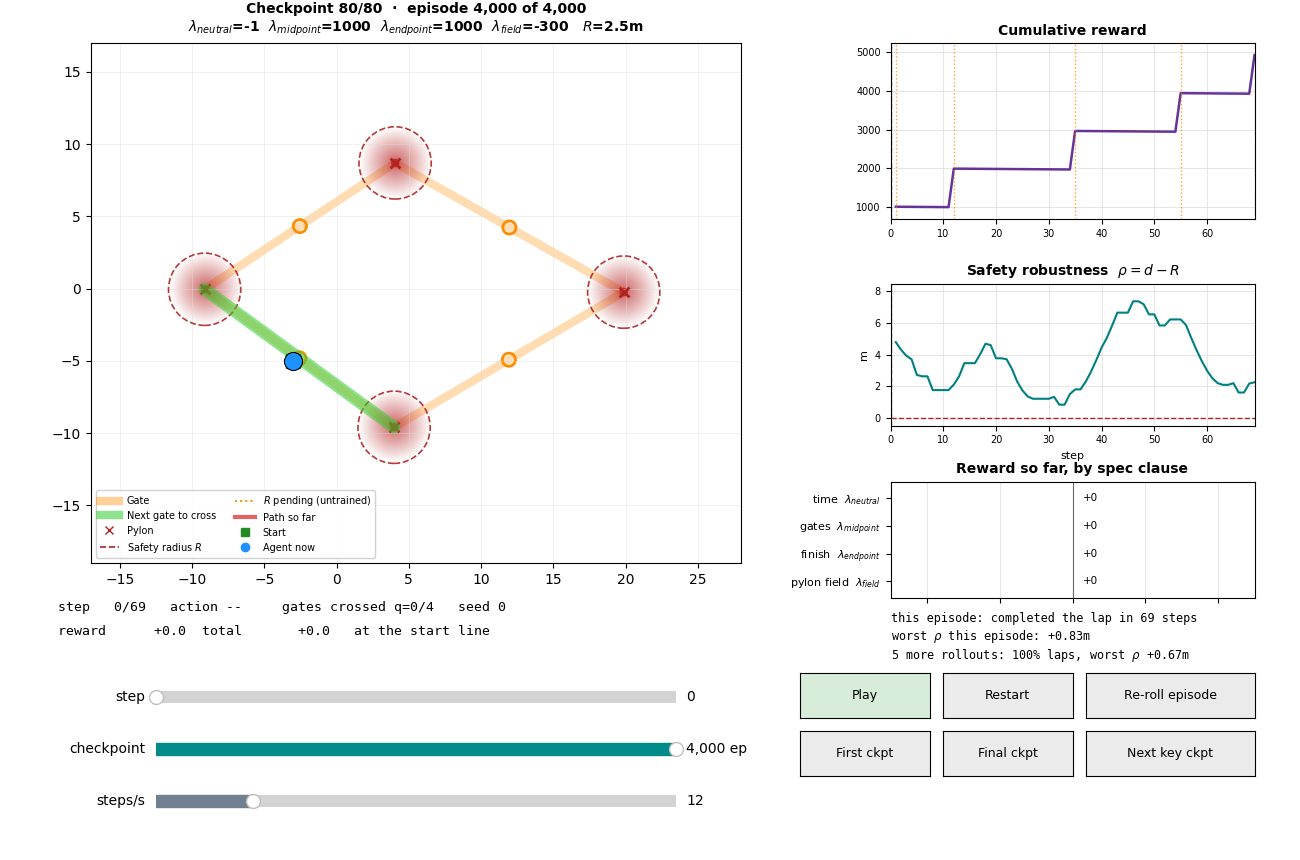

In [20]:
# plt.ioff() keeps the figure from being displayed twice: we display its canvas ourselves
plt.ioff()
dashboard = ReplayDashboard(run)
plt.ion()
display(dashboard.fig.canvas)

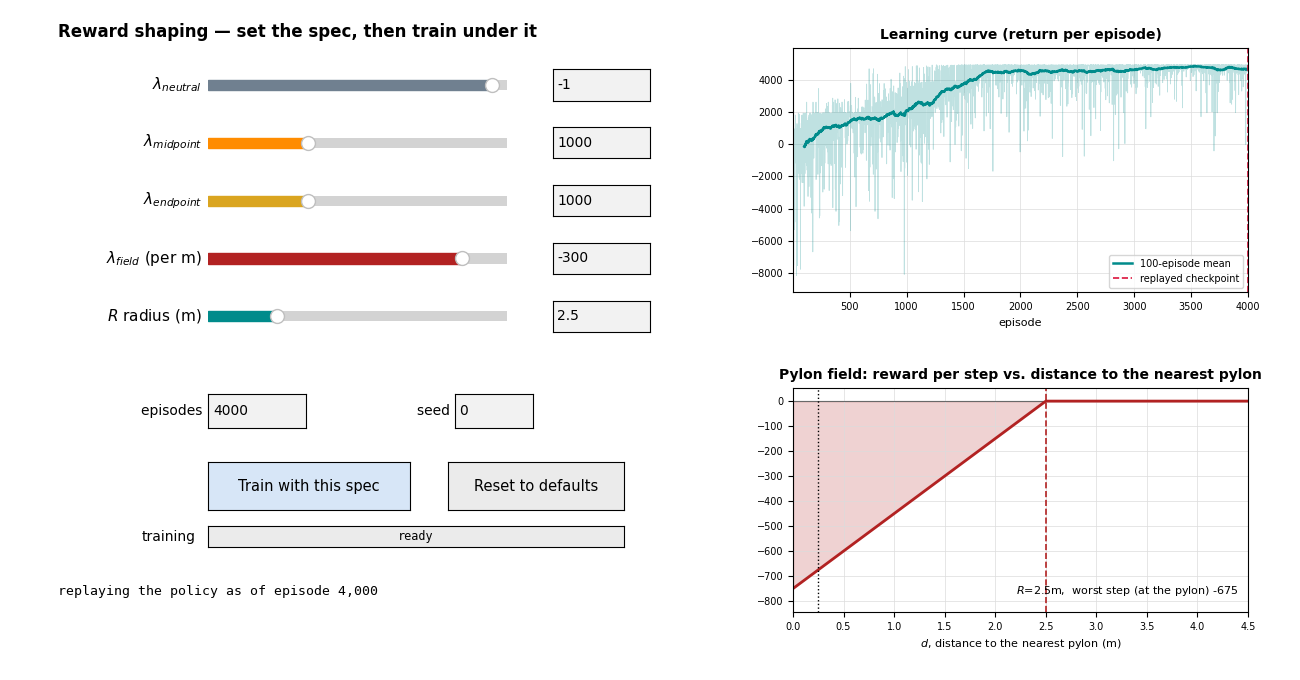

In [ ]:
plt.ioff()
panel = RewardPanel(dashboard)
plt.ion()
display(panel.fig.canvas)